<a href="https://colab.research.google.com/github/MahfoudhSen/Aimed/blob/main/model-affordability/affordability_score_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Housing Affordability Score — v2

Builds on v1 with three targeted improvements:

| Improvement | Why |
|-------------|-----|
| **Interaction features** | Expose relationships the model can't easily discover on its own (e.g. income-per-capita, utility load per person) |
| **RF hyperparameter tuning** | `GridSearchCV` over depth, estimators, and split criteria to squeeze more signal from the Random Forest |
| **XGBoost** | Gradient boosting typically outperforms bagged forests on tabular data; used as a direct comparison |

**Pipeline:**
1. Fetch & clean ACS PUMS data
2. Build affordability label (same weighted composite as v1)
3. Engineer raw + interaction features
4. Tune & evaluate Random Forest
5. Train & evaluate XGBoost
6. Compare models and visualize

## 1. Imports

In [ ]:
import os
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

RANDOM_STATE = 42

## 2. Fetch Data

**ACS 1-Year PUMS — New York State (FIPS 36)**

| Variable | Description |
|----------|-------------|
| `HINCP`  | Annual household income |
| `GRPIP`  | Gross rent as % of income (Census-computed) |
| `PUMA`   | Public Use Microdata Area (geography) |
| `NP`     | Number of persons in household |
| `BDSP`   | Number of bedrooms (0 = studio) |
| `ELEP`   | Monthly electricity cost |
| `GASP`   | Monthly gas cost |
| `FULP`   | Annual other heating fuel cost |
| `FS`     | SNAP/food-stamp receipt (1 = yes, 2 = no) |
| `VEH`    | Vehicles available (0 = none) |
| `DIS`    | Disability status (1 = yes, 2 = no) |
| `ESR`    | Employment status (1–6, one-hot encoded) |


In [ ]:
import os
from getpass import getpass

os.environ["CENSUS_API_KEY"] = getpass("Enter Census API key: ")

Enter Census API key: ··········


In [ ]:
API_KEY = os.environ.get("CENSUS_API_KEY", "")
if not API_KEY:
    raise EnvironmentError(
        "Census API key not found. "
        "Set the CENSUS_API_KEY environment variable before running."
    )

VARIABLES = "HINCP,FULP,PUMA,GASP,GRPIP,NP,ELEP,BDSP,FS,VEH,DIS,ESR"
url = (
    f"https://api.census.gov/data/2024/acs/acs1/pums"
    f"?get={VARIABLES}&for=state:36&key={API_KEY}"
)
response = requests.get(url)
response.raise_for_status()
print(f"Status: {response.status_code}")

Status: 200


## 3. Clean & Filter

In [ ]:
raw = response.json()
df = pd.DataFrame(raw[1:], columns=raw[0])

NUM_COLS = ["HINCP", "GRPIP", "PUMA", "NP", "BDSP", "ELEP", "GASP", "FULP", "FS"]
df[NUM_COLS] = df[NUM_COLS].apply(pd.to_numeric, errors="coerce").fillna(0)

# Filter to NYC renters (PUMA 3701-4114 = all five boroughs)
df_nyc = df[
    df["HINCP"].between(10_000, 300_000) &
    df["GRPIP"].between(1, 98) &
    df["PUMA"].between(3701, 4114)
].copy().reset_index(drop=True)

# Sentinel values 1-2 mean "utilities included in rent" — zero them out
for col in ["ELEP", "GASP", "FULP"]:
    df_nyc.loc[df_nyc[col] <= 2, col] = 0

# Recode SNAP: 1 = received, 0 = did not receive
df_nyc["FS"] = df_nyc["FS"].map({1: 1, 2: 0})

print(f"NYC renter households: {len(df_nyc):,}")
df_nyc[["HINCP", "GRPIP", "NP", "BDSP"]].describe().round(1)

NYC renter households: 1,877


,HINCP,GRPIP,NP,BDSP
count,1877.0,1877.0,1877.0,1877.0
mean,104080.8,32.0,1.9,1.5
std,71898.7,18.5,1.2,1.0
min,10000.0,1.0,1.0,0.0
25%,44200.0,19.0,1.0,1.0
50%,90000.0,28.0,2.0,1.0
75%,150000.0,41.0,2.0,2.0
max,300000.0,97.0,12.0,6.0


## 4. Build Label + Interaction Features

### Affordability label (same as v1)

| Component | Weight | Rationale |
|-----------|--------|-----------|
| Rent burden (`GRPIP / 100`) | 50% | Standard HUD benchmark |
| Utility burden (utilities / monthly income) | 30% | Hidden cost often missed |
| Space stress (`NP / (BDSP + 1)`, normed) | 20% | Proxy for overcrowding |

Higher = **less affordable**. Clipped to [0, 1].

### Interaction features (new in v2)
These capture relationships between raw variables that a tree model would need many splits to approximate on its own.

| Feature | Formula | Captures |
|---------|---------|----------|
| `income_per_capita` | `HINCP / NP` | Income available per household member |
| `util_total` | `ELEP + GASP + FULP/12` | Total monthly utility spend |
| `util_per_capita` | `util_total / NP` | Utility load per person |
| `income_x_size` | `HINCP × NP` | Joint income-size signal |
| `util_x_size` | `util_total × NP` | Joint utility-size signal |
| `room_density` | `NP / (BDSP + 1)` | Overcrowding proxy |
| `log_income` | `log(HINCP)` | Compresses income skew |
| `snap_x_size` | `FS × NP` | SNAP status weighted by household size |

In [ ]:
# ── Intermediates for label only (not used as features) ──────────────────────
df_nyc["monthly_income"] = df_nyc["HINCP"] / 12
df_nyc["util_costs"]     = df_nyc["ELEP"] + df_nyc["GASP"] + df_nyc["FULP"] / 12
df_nyc["util_burden"]    = (df_nyc["util_costs"] / df_nyc["monthly_income"]).clip(0, 1)
df_nyc["space_stress"]   = (df_nyc["NP"] / (df_nyc["BDSP"] + 1)).clip(0, 3)
df_nyc["rent_burden"]    = df_nyc["GRPIP"] / 100

# ── Composite affordability label ────────────────────────────────────────────
df_nyc["affordability_score"] = (
    0.50 * df_nyc["rent_burden"] +
    0.30 * df_nyc["util_burden"] +
    0.20 * (df_nyc["space_stress"] / 3)
).clip(0, 1)

# ── Interaction features (safe to use as model inputs) ───────────────────────
df_nyc["income_per_capita"] = df_nyc["HINCP"] / df_nyc["NP"]
df_nyc["util_total"]        = df_nyc["util_costs"]          # monthly total
df_nyc["util_per_capita"]   = df_nyc["util_total"] / df_nyc["NP"]
df_nyc["income_x_size"]     = df_nyc["HINCP"] * df_nyc["NP"]
df_nyc["util_x_size"]       = df_nyc["util_total"] * df_nyc["NP"]
df_nyc["room_density"]      = df_nyc["NP"] / (df_nyc["BDSP"] + 1)
df_nyc["log_income"]        = np.log1p(df_nyc["HINCP"])
df_nyc["snap_x_size"]       = df_nyc["FS"] * df_nyc["NP"]

print("Label distribution:")
print(df_nyc["affordability_score"].describe().round(3))

Label distribution:
count    1877.000
mean        0.221
std         0.098
min         0.032
25%         0.154
50%         0.198
75%         0.266
max         0.695
Name: affordability_score, dtype: float64


## 5. Train / Test Split

In [ ]:
RAW_FEATURES = ["HINCP", "NP", "BDSP", "ELEP", "GASP", "FULP", "FS", "PUMA", "VEH", "DIS", "ESR"]
INTERACTION_FEATURES = [
    "income_per_capita", "util_total", "util_per_capita",
    "income_x_size", "util_x_size", "room_density",
    "log_income", "snap_x_size"
]
TARGET = "affordability_score"

# One-hot encode geography, then append interaction features
X_base = pd.get_dummies(df_nyc[RAW_FEATURES], columns=["PUMA"], drop_first=True)
X = pd.concat([X_base, df_nyc[INTERACTION_FEATURES]], axis=1)
y = df_nyc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}   Features: {X.shape[1]}")

Train: 1,501   Test: 376   Features: 22


## 6. Random Forest — Baseline vs Tuned

`GridSearchCV` with 5-fold CV searches over the most impactful RF hyperparameters:

| Parameter | Grid | Controls |
|-----------|------|----------|
| `n_estimators` | 200, 400 | Number of trees |
| `max_depth` | None, 15, 25 | Max tree depth (None = unlimited) |
| `min_samples_leaf` | 1, 3, 5 | Min samples to form a leaf — controls overfitting |
| `max_features` | `"sqrt"`, `0.5` | Features considered per split |

In [ ]:
# ── Baseline RF (v1 settings) ─────────────────────────────────────────────────
rf_base = RandomForestRegressor(n_estimators=200, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_rf_base = rf_base.predict(X_test)

mae_rf_base = mean_absolute_error(y_test, y_pred_rf_base)
r2_rf_base  = r2_score(y_test, y_pred_rf_base)
print(f"RF Baseline  — MAE: {mae_rf_base:.4f}   R²: {r2_rf_base:.4f}")

# ── Tuned RF via GridSearchCV ─────────────────────────────────────────────────
param_grid = {
    "n_estimators":     [200, 400],
    "max_depth":        [None, 15, 25],
    "min_samples_leaf": [1, 3, 5],
    "max_features":     ["sqrt", 0.5],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

print(f"\nBest params: {rf_grid.best_params_}")
print(f"Best CV R²:  {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)
print(f"\nRF Tuned     — MAE: {mae_rf:.4f}   R²: {r2_rf:.4f}")

RF Baseline  — MAE: 0.0551   R²: 0.3768
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}
Best CV R²:  0.4323

RF Tuned     — MAE: 0.0543   R²: 0.3998


## 7. XGBoost

Gradient Boosting builds trees **sequentially**, each correcting residuals from the previous one. Key advantages over Random Forest on tabular data:
- Directly optimises a loss function (better bias reduction)
- Regularisation parameters (`reg_alpha`, `reg_lambda`) reduce overfitting
- Typically needs fewer trees to achieve the same accuracy

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    "n_estimators":    randint(100, 600),
    "learning_rate":   uniform(0.01, 0.15),
    "max_depth":       randint(3, 8),
    "subsample":       uniform(0.6, 0.4),
    "colsample_bytree":uniform(0.6, 0.4),
    "reg_alpha":       uniform(0.0, 1.0),
    "reg_lambda":      uniform(0.5, 2.5),
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    param_dist,
    n_iter=40,
    cv=3,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
xgb_search.fit(X_train, y_train)

print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV R²:  {xgb_search.best_score_:.4f}")

xgb = xgb_search.best_estimator_
y_pred_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb  = r2_score(y_test, y_pred_xgb)
print(f"\nXGBoost Tuned — MAE: {mae_xgb:.4f}   R²: {r2_xgb:.4f}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best params: {'colsample_bytree': np.float64(0.7203513239267079), 'learning_rate': np.float64(0.052726074156620145), 'max_depth': 3, 'n_estimators': 286, 'reg_alpha': np.float64(0.6095643339798968), 'reg_lambda': np.float64(1.7566975580721538), 'subsample': np.float64(0.6205915004999957)}
Best CV R²:  0.4587

XGBoost Tuned — MAE: 0.0533   R²: 0.4169


## 8. Results Comparison

In [ ]:
# ── 8a. Summary table ────────────────────────────────────────────────────────
results = pd.DataFrame({
    "Model": ["RF Baseline (v1)", "RF Tuned", "XGBoost"],
    "MAE":   [mae_rf_base, mae_rf, mae_xgb],
    "R²":    [r2_rf_base,  r2_rf,  r2_xgb],
})
results["MAE"] = results["MAE"].round(4)
results["R²"]  = results["R²"].round(4)
print(results.to_string(index=False))

           Model    MAE     R²
RF Baseline (v1) 0.0551 0.3768
        RF Tuned 0.0543 0.3998
         XGBoost 0.0533 0.4169


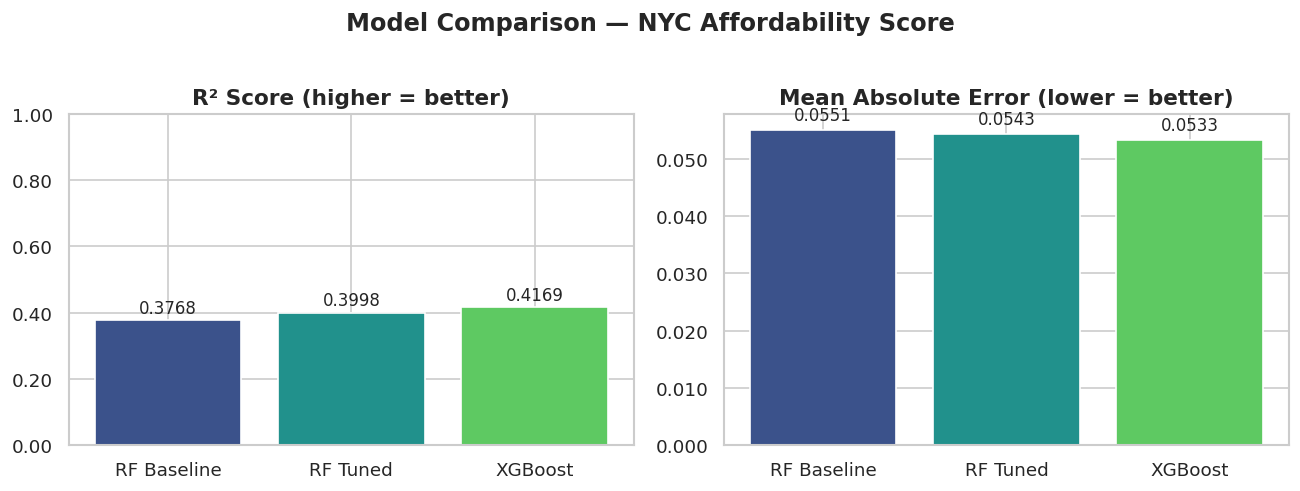

In [ ]:
# ── 8b. Model comparison bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = sns.color_palette("viridis", 3)
models = ["RF Baseline", "RF Tuned", "XGBoost"]

# R²
bars_r2 = axes[0].bar(models, results["R²"], color=colors, edgecolor="white")
axes[0].set_title("R² Score (higher = better)", fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
for bar, val in zip(bars_r2, results["R²"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10)

# MAE
bars_mae = axes[1].bar(models, results["MAE"], color=colors, edgecolor="white")
axes[1].set_title("Mean Absolute Error (lower = better)", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
for bar, val in zip(bars_mae, results["MAE"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Model Comparison — NYC Affordability Score", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

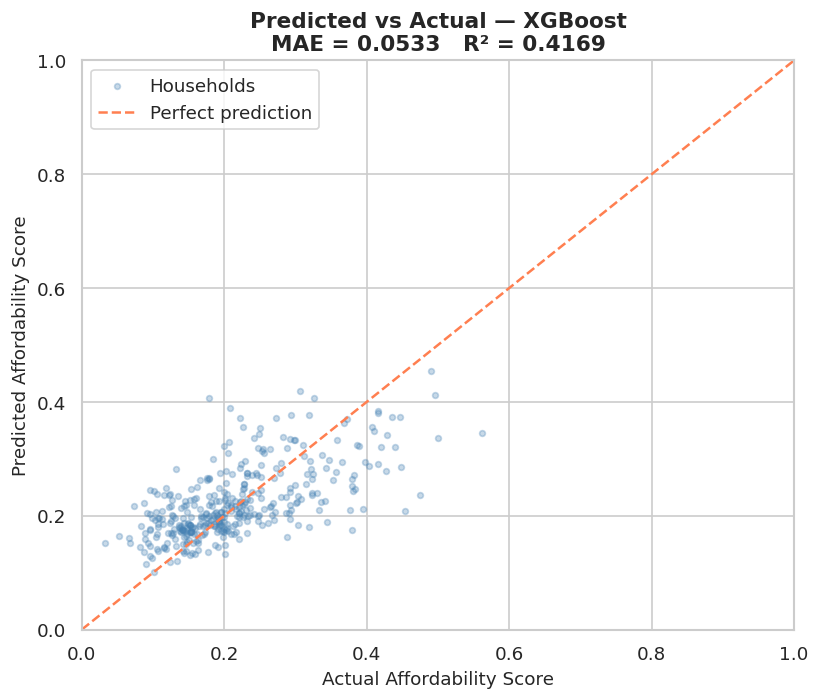

In [ ]:
# ── 8c. Predicted vs Actual — best model ─────────────────────────────────────
# Pick the model with the highest R²
best_idx  = results["R²"].idxmax()
best_name = results.loc[best_idx, "Model"]
best_pred = {"RF Baseline (v1)": y_pred_rf_base, "RF Tuned": y_pred_rf, "XGBoost": y_pred_xgb}[best_name]
best_mae  = results.loc[best_idx, "MAE"]
best_r2   = results.loc[best_idx, "R²"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, best_pred, alpha=0.3, s=12, color="steelblue", label="Households")
ax.plot([0, 1], [0, 1], "--", color="coral", linewidth=1.5, label="Perfect prediction")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Actual Affordability Score")
ax.set_ylabel("Predicted Affordability Score")
ax.set_title(
    f"Predicted vs Actual — {best_name}\nMAE = {best_mae:.4f}   R² = {best_r2:.4f}",
    fontweight="bold"
)
ax.legend()
plt.tight_layout()
plt.show()

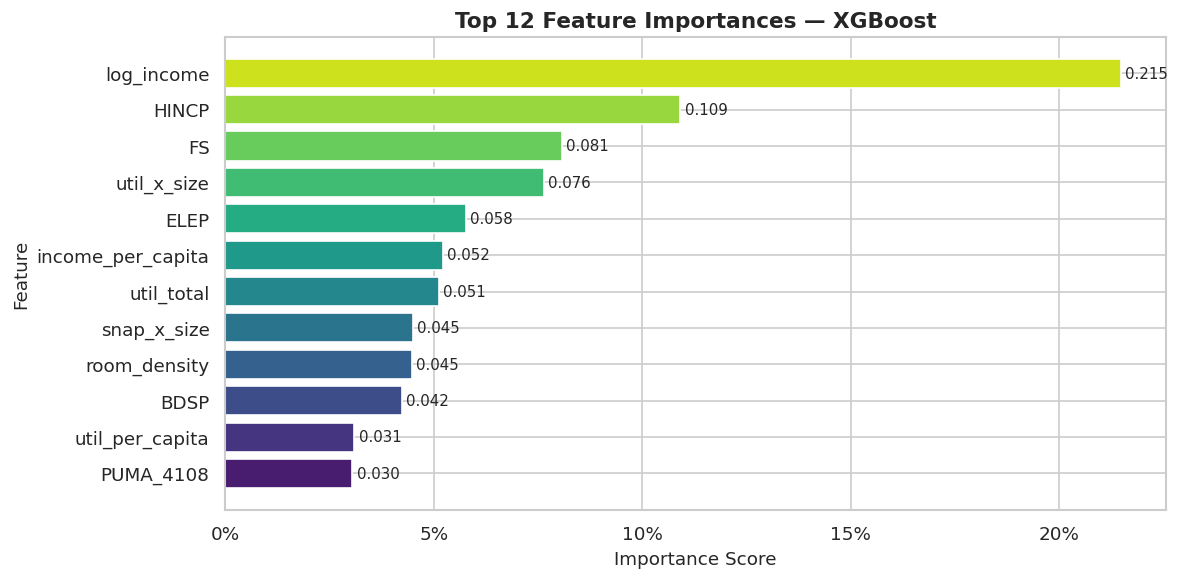

In [ ]:
# ── 8d. Feature importance — best model ──────────────────────────────────────
TOP_N = 12

if "XGBoost" in best_name:
    importances = xgb.feature_importances_
else:
    importances = rf_best.feature_importances_

feat_imp = (
    pd.Series(importances, index=X.columns)
    .sort_values(ascending=False)
    .head(TOP_N)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    feat_imp.index[::-1],
    feat_imp.values[::-1],
    color=sns.color_palette("viridis", TOP_N)
)
for bar, val in zip(bars, feat_imp.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_title(f"Top {TOP_N} Feature Importances — {best_name}", fontweight="bold")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

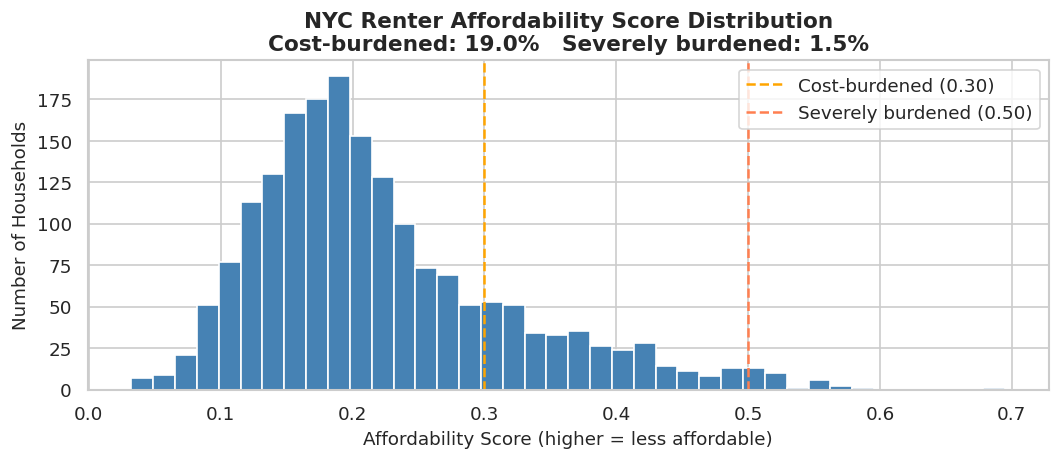

In [ ]:
# ── 8e. Score distribution with burden thresholds ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_nyc["affordability_score"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Cost-burdened (0.30)")
ax.axvline(0.50, color="coral",  linestyle="--", linewidth=1.5, label="Severely burdened (0.50)")

pct_burdened = (df_nyc["affordability_score"] >= 0.30).mean() * 100
pct_severe   = (df_nyc["affordability_score"] >= 0.50).mean() * 100

ax.set_title(
    f"NYC Renter Affordability Score Distribution\n"
    f"Cost-burdened: {pct_burdened:.1f}%   Severely burdened: {pct_severe:.1f}%",
    fontweight="bold"
)
ax.set_xlabel("Affordability Score (higher = less affordable)")
ax.set_ylabel("Number of Households")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os
from google.colab import files

os.makedirs("models", exist_ok=True)

joblib.dump(xgb, "models/affordability_model.pkl")
joblib.dump(list(X.columns), "models/affordability_features.pkl")

files.download("models/affordability_model.pkl")
files.download("models/affordability_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>